# Приоритизация гипотез и анализ результатов A/B-теста интернет-магазина

Интернет-магазин подготовил ряд продуктовых гипотез, направленных на увеличение выручки. Для выбора наиболее перспективной инициативы проведена приоритизация гипотез, после чего выполнен анализ результатов A/B-теста.

#### Цель проекта

Определить наиболее перспективные продуктовые инициативы и оценить влияние изменений на ключевые метрики интернет-магазина с помощью A/B-тестирования.

# Приоритизация продуктовых гипотез

Для оценки потенциальных инициатив по росту выручки проанализируем 9 гипотез с параметрами Reach, Impact, Confidence и Effort.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import datetime as dt
pd.options.display.max_colwidth=150

In [2]:
hypothesis = pd.read_csv('hypothesis.csv')
hypothesis

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


Методы приоритезации:
- ICE Score = (Impact x Confidence) / Efforts
- RICE Score = (Reach x Impact x Confidence) / Efforts

Фреймворк RICE состоит из четырёх компонентов:
- Reach — скольких пользователей затронет изменение, которое вы хотите внести;
- Impact — насколько сильно изменение повлияет на пользователей, их опыт и удовлетворение от продукта;
- Confidence — насколько вы уверены, что это изменение повлияет на пользователей именно так; 
- Efforts — сколько стоит протестировать эту гипотезу. 

## Оценка гипотез по фреймворку ICE

In [3]:
hypothesis['Ice'] = round(hypothesis['Impact'] * hypothesis['Confidence'] / hypothesis['Efforts'], 2)
hypothesis.sort_values(by='Ice', ascending=False)

,Hypothesis,Reach,Impact,Confidence,Efforts,Ice
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


## Оценка гипотез по фреймворку RICE

In [4]:
hypothesis['Rice'] = round(hypothesis['Reach'] * hypothesis['Impact'] * hypothesis['Confidence'] / hypothesis['Efforts'], 2)
hypothesis.sort_values(by='Rice', ascending=False)

,Hypothesis,Reach,Impact,Confidence,Efforts,Ice,Rice
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.0


## Сравнение результатов ICE и RICE

При использовании RICE приоритет гипотез изменился из-за учета параметра Reach. Гипотезы с высоким охватом пользователей получили преимущество, даже если их Impact был ниже. Топ-1 гипотеза 8 по ICE теперь заняла только 5 место, имея при это самый низкие показатель Reach среди всех гипотез. А на 1ое место вышла гипотеза 7, с Reach 10, ранее занимавшая 3е место. В ICE она занимала 3 место. А вот последние 4 места почти не изменились. 



# Анализ результатов A/B-теста

Для оценки влияния изменений на поведение пользователей проанализируем результаты проведённого A/B-теста.

## Подготовка данных

#### Orders

In [5]:
orders = pd.read_csv('orders.csv')
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [6]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   transactionId  1197 non-null   int64
 1   visitorId      1197 non-null   int64
 2   date           1197 non-null   str  
 3   revenue        1197 non-null   int64
 4   group          1197 non-null   str  
dtypes: int64(3), str(2)
memory usage: 46.9 KB


In [7]:
orders.isna().sum()

transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

Пропусков в данных не обнаружено. 

Скорректируем названия колонок и формат дат. 

In [8]:
orders.columns = orders.columns.str.replace('Id', '_id')
orders.columns

Index(['transaction_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='str')

In [9]:
orders['date'] = pd.to_datetime(orders['date'])
orders['date']

0      2019-08-15
1      2019-08-15
2      2019-08-15
3      2019-08-15
4      2019-08-15
          ...    
1192   2019-08-14
1193   2019-08-14
1194   2019-08-14
1195   2019-08-14
1196   2019-08-15
Name: date, Length: 1197, dtype: datetime64[us]

In [10]:
orders.duplicated().sum()

np.int64(0)

Дубликатов не обнаружено. 

In [11]:
min(orders['date'] ), max(orders['date'])

(Timestamp('2019-08-01 00:00:00'), Timestamp('2019-08-31 00:00:00'))

Период соответсвует выбранному для анализа. 

#### Visitors

In [12]:
visitors = pd.read_csv('visitors.csv')
visitors.head()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [13]:
visitors.info()

<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      62 non-null     str  
 1   group     62 non-null     str  
 2   visitors  62 non-null     int64
dtypes: int64(1), str(2)
memory usage: 1.6 KB


In [14]:
visitors.isna().sum()

date        0
group       0
visitors    0
dtype: int64

Пропусков в данных не обнаружено. 

Скорректируем формат дат. 

In [15]:
visitors['date'] = pd.to_datetime(visitors['date'])
visitors['date']

0    2019-08-01
1    2019-08-02
2    2019-08-03
3    2019-08-04
4    2019-08-05
        ...    
57   2019-08-27
58   2019-08-28
59   2019-08-29
60   2019-08-30
61   2019-08-31
Name: date, Length: 62, dtype: datetime64[us]

In [16]:
visitors.duplicated().sum()

np.int64(0)

Дубликатов не обнаружено. 

In [17]:
min(visitors['date'] ), max(visitors['date'])

(Timestamp('2019-08-01 00:00:00'), Timestamp('2019-08-31 00:00:00'))

Период соответсвует выбранному для анализа. 

## Проверка групп A/B на однородность

In [18]:
print('Количество посетителей в группе А: {0}'.format((visitors.query('group == "A"')['visitors'].sum())))
print('Количество посетителей в группе B: {0}'.format((visitors.query('group == "B"')['visitors'].sum())))

Количество посетителей в группе А: 18736
Количество посетителей в группе B: 18916


In [19]:
print('Количество уникальных пользователей в группе A:', orders.query("group == 'A'")['visitor_id'].nunique())
print('Количество уникальных пользователей в группе B:', orders.query("group == 'B'")['visitor_id'].nunique())

Количество уникальных пользователей в группе A: 503
Количество уникальных пользователей в группе B: 586


Размеры групп и количество посетителей сопоставимы, критичных перекосов в распределении трафика не обнаружено.

## Проверка групп A/B на пересечение пользователей

In [20]:
both_group_users = list(set(orders.query("group == 'A'")['visitor_id']) & set(orders.query("group == 'B'")['visitor_id']))
print('Доля пользователей, попавших в обе группы: {:.2%}'.format(len(both_group_users) / orders['visitor_id'].nunique()))

Доля пользователей, попавших в обе группы: 5.63%


Наличие пересечений между группами нарушает корректность A/B-теста, поэтому удаляем таких пользователей из анализа.

In [21]:
orders = orders[~orders['visitor_id'].isin(both_group_users)]

Для анализа динамики метрик создадим кумулятивные показатели по группам теста.

In [22]:
ordersADaily = (orders[orders['group'] == 'A'][['date', 'transaction_id', 'visitor_id', 'revenue']]
                    .groupby('date', as_index=False)
                    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'}))

ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']

ordersACummulative = ordersADaily.apply(lambda x: ordersADaily[ordersADaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateA': 'sum', 'revenuePerDateA': 'sum'}),
         axis=1).sort_values(by=['date'])

ordersACummulative.columns = ['date', 'ordersCummulativeA', 'revenueCummulativeA']

ordersBDaily = (orders[orders['group'] == 'B'][['date', 'transaction_id', 'visitor_id', 'revenue']]
                    .groupby('date', as_index=False)
                    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'}))

ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']

ordersBCummulative = ordersBDaily.apply(lambda x: ordersBDaily[ordersBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateB': 'sum', 'revenuePerDateB': 'sum'}),
        axis=1).sort_values(by=['date'])

ordersBCummulative.columns = ['date', 'ordersCummulativeB', 'revenueCummulativeB']

In [23]:
visitorsADaily = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

visitorsACummulative = visitorsADaily.apply(lambda x: visitorsADaily[visitorsADaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateA': 'sum'}), axis=1)

visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

visitorsBDaily = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

visitorsBCummulative = visitorsBDaily.apply(lambda x: visitorsBDaily[visitorsBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateB': 'sum'}), axis=1)

visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

In [24]:
data = (ordersADaily.merge(ordersBDaily, left_on='date', right_on='date', how='left')
    .merge(ordersACummulative, left_on='date', right_on='date', how='left')
    .merge(ordersBCummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsADaily, left_on='date', right_on='date', how='left')
    .merge(visitorsBDaily, left_on='date', right_on='date', how='left')
    .merge(visitorsACummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsBCummulative, left_on='date', right_on='date', how='left'))

data.head(5)

,date,ordersPerDateA,revenuePerDateA,ordersPerDateB,revenuePerDateB,ordersCummulativeA,revenueCummulativeA,ordersCummulativeB,revenueCummulativeB,visitorsPerDateA,visitorsPerDateB,visitorsCummulativeA,visitorsCummulativeB
0,2019-08-01,23,142779,17,59758,23,142779,17,59758,719,713,719,713
1,2019-08-02,19,91602,23,162043,42,234381,40,221801,619,581,1338,1294
2,2019-08-03,24,112473,14,67049,66,346854,54,288850,507,509,1845,1803
3,2019-08-04,11,41176,14,96890,77,388030,68,385740,717,770,2562,2573
4,2019-08-05,22,86383,21,89908,99,474413,89,475648,756,707,3318,3280


### Кумулятивная выручка по группам

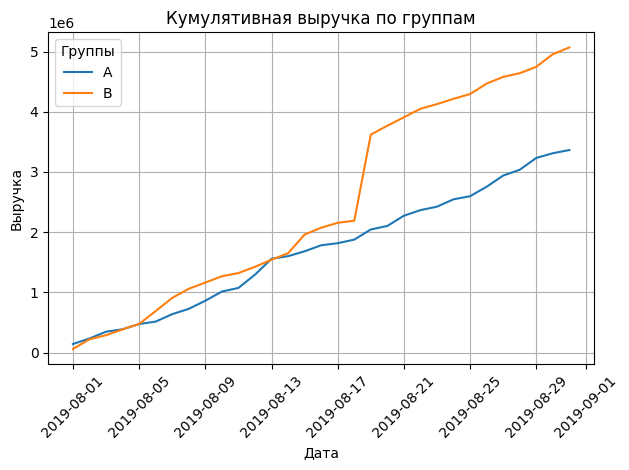

In [25]:
plt.plot(data['date'], data['revenueCummulativeA'], label='A')
plt.plot(data['date'], data['revenueCummulativeB'], label='B')

#orders.loc[orders['group']=='A'].groupby('date')['revenue'].agg('sum').cumsum().plot(label='A')
#orders.loc[orders['group']=='B'].groupby('date')['revenue'].agg('sum').cumsum().plot(label='B')

plt.title('Кумулятивная выручка по группам')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.legend(title='Группы')
plt.grid()
plt.tight_layout()


На протяжении большей части эксперимента кумулятивная выручка группы B превышает показатели группы A. Однако резкий скачок в отдельный период может свидетельствовать о влиянии крупных заказов, поэтому для подтверждения эффекта необходимо дополнительно исследовать выбросы.

### Кумулятивный средний чек по группам

Рассчитаем кумулятивный средний чек для каждой группы теста.

In [26]:
data['avgBillCummulativeA'] = data['revenueCummulativeA'] / data['ordersCummulativeA']
data['avgBillCummulativeB'] = data['revenueCummulativeB'] / data['ordersCummulativeB']

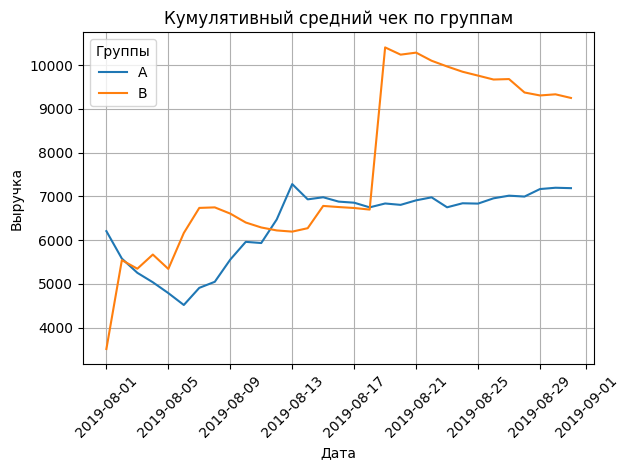

In [27]:
plt.plot(data['date'], data['avgBillCummulativeA'], label='A')
plt.plot(data['date'], data['avgBillCummulativeB'], label='B')

#orders.loc[orders['group']=='A'].groupby('date')['revenue'].agg('sum').cumsum().plot(label='A')
#orders.loc[orders['group']=='B'].groupby('date')['revenue'].agg('sum').cumsum().plot(label='B')


plt.title('Кумулятивный средний чек по группам')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.legend(title='Группы')
plt.grid()
plt.tight_layout()

К концу теста средний чек группы A стабилизировался. Средний чек группы B постепенно снижается после резких скачков, что может свидетельствовать о влиянии аномально дорогих заказов в начале теста.

### Относительное изменение кумулятивного среднего чека группы B к группе A

График относительного различия (рассчитывается по формуле: Кумулятивная метрика группы B / Кумулятивная метрика группы A - 1)

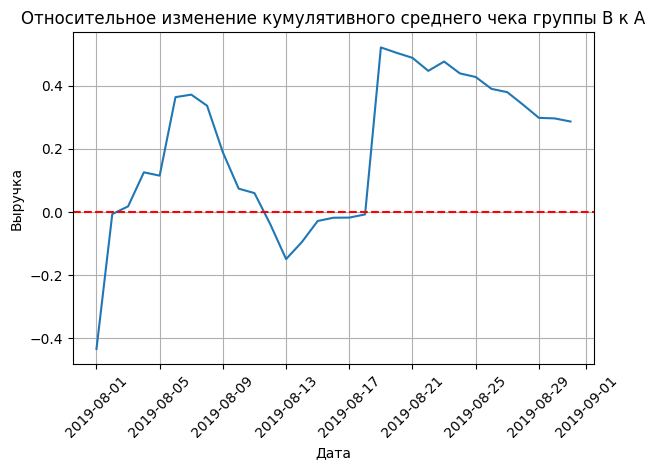

In [28]:
plt.plot(data['date'], data['avgBillCummulativeB'] / data['avgBillCummulativeA'] - 1)


plt.axhline(y=0, color='red', linestyle='--')

plt.title('Относительное изменение кумулятивного среднего чека группы B к А')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

График относительного изменения среднего чека нестабилен и резко меняется в нескольких точках. Это может указывать на наличие аномально дорогих заказов, которые существенно влияют на средний чек.

### Кумулятивное среднее количество заказов на посетителя по группам

In [29]:
data['avgOrdersCummCntA'] = data['ordersCummulativeA'] / data['visitorsCummulativeA']
data['avgOrdersCummCntB'] = data['ordersCummulativeB'] / data['visitorsCummulativeB']

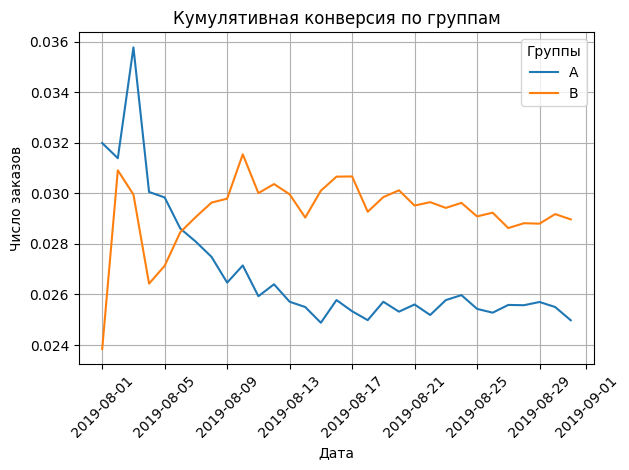

In [30]:
plt.plot(data['date'], data['avgOrdersCummCntA'], label='A')
plt.plot(data['date'], data['avgOrdersCummCntB'], label='B')

plt.title('Кумулятивная конверсия по группам')
plt.xlabel('Дата')
plt.ylabel('Число заказов')
plt.legend(title='Группы')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

Кумулятивная конверсия группы B после некоторых колебаний в начале теста установилась на уровне 0.029, что выше значения у группы А 0.025. 

### Относительное изменение кумулятивного среднего количества заказов на посетителя группы B к группе A

Рассчитывается по формуле: Кумулятивная метрика группы B / Кумулятивная метрика группы A - 1

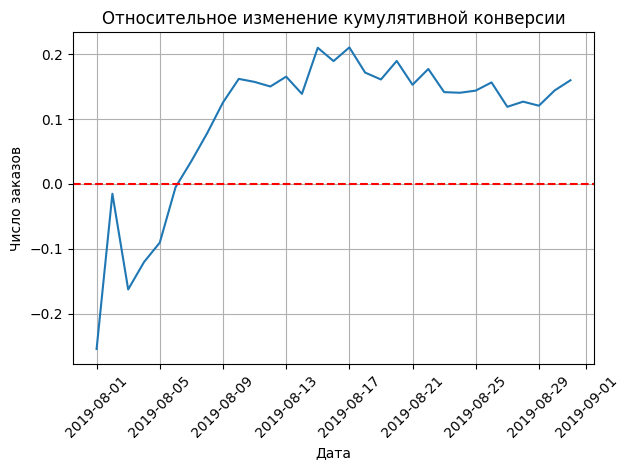

In [31]:
plt.plot(data['date'], data['avgOrdersCummCntB']/data['avgOrdersCummCntA']-1)

plt.axhline(y=0, color='red', linestyle='--')

plt.title('Относительное изменение кумулятивной конверсии')
plt.xlabel('Дата')
plt.ylabel('Число заказов')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

После середины теста группа B стабильно показывает более высокую конверсию относительно группы A. Относительный прирост удерживается примерно на уровне 15%.

### Количество заказов по пользователям

In [32]:
# создание сводной таблицы с числом заказов на каждого покупателя

df_cnt_orders = (orders.groupby('visitor_id', as_index=False)
                        .agg({'transaction_id': 'nunique', 'group': 'max'}))

df_cnt_orders.columns = ['visitor_id','trans_cnt', 'group']
df_cnt_orders

,visitor_id,trans_cnt,group
0,5114589,1,B
1,6958315,1,B
2,11685486,1,A
3,39475350,1,B
4,47206413,1,B
...,...,...,...
968,4259830713,1,A
969,4278982564,1,A
970,4279090005,1,B
971,4281247801,1,B


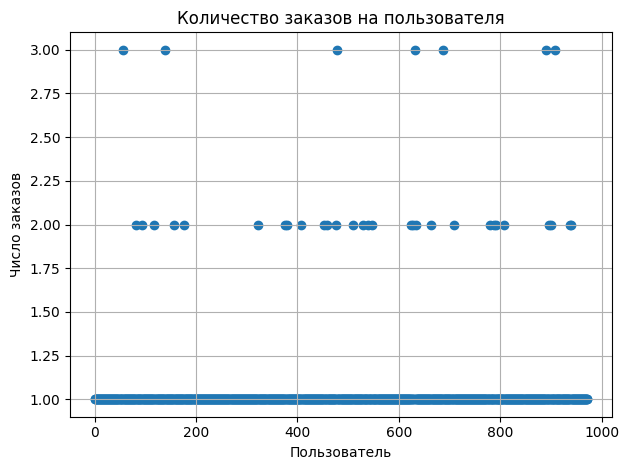

In [33]:
x_values = pd.Series(range(0,len(df_cnt_orders['trans_cnt'])))
plt.scatter(x_values, df_cnt_orders['trans_cnt']) 

plt.title('Количество заказов на пользователя')
plt.xlabel('Пользователь')
plt.ylabel('Число заказов')
plt.grid()
plt.tight_layout()


Большинство пользователей совершают 1 заказ. Пользователей с 2 заказами значительно меньше, а пользователей с 3 заказами - единицы.

### Граница для опеделения аномальных пользователей

In [34]:
print('95-ый перцентиль количества заказов на пользователя:', np.percentile(df_cnt_orders['trans_cnt'], 95))
print('99-ый перцентиль количества заказов на пользователя:', np.percentile(df_cnt_orders['trans_cnt'], 99))

95-ый перцентиль количества заказов на пользователя: 1.0
99-ый перцентиль количества заказов на пользователя: 2.0


Не более 5% пользователей совершили более 1 заказа, и не более 1% пользователей более 2 заказов.

Пользователи с двумя заказами всё ещё могут считаться частью нормального пользовательского поведения для интернет-магазина, поэтому использование порога более 1 заказа привело бы к слишком агрессивной фильтрации данных. В качестве границы для аномальных пользователей выберем более 2 заказов.

### Стоимость заказов

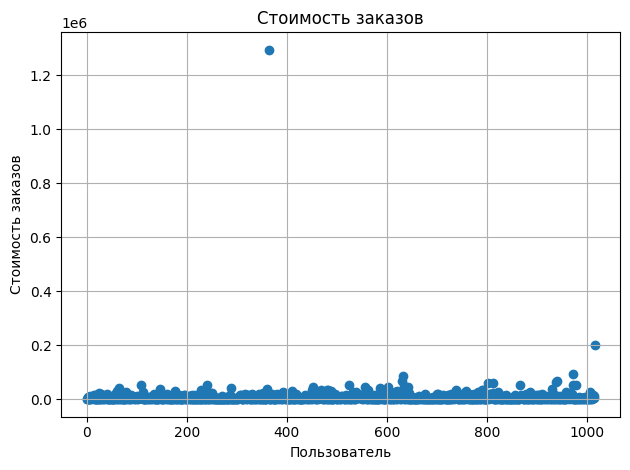

In [35]:
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue']) 

plt.title('Стоимость заказов')
plt.xlabel('Пользователь')
plt.ylabel('Стоимость заказов')
plt.grid()
plt.tight_layout()

Видим несколько аномально больших заказов, из-за которых остальные данные сконцентрировались в нижней части графика. Ограничим ось У для получения наглядных результатов. 

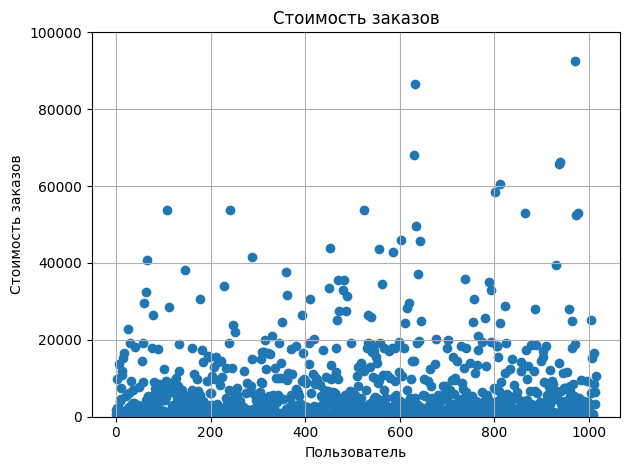

In [36]:
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue']) 
plt.ylim((0,100000))

plt.title('Стоимость заказов')
plt.xlabel('Пользователь')
plt.ylabel('Стоимость заказов')
plt.grid()
plt.tight_layout()

Большая часть заказов имеет сравнительно небольшую стоимость, однако присутствуют отдельные крайне дорогие заказы, которые существенно растягивают распределение. Определим границу аномальных значений с помощью перцентилей. 

### Граница для определения аномальных заказов

In [37]:
print('95-ый перцентиль стоимости заказа:', round(np.percentile(orders['revenue'], 95),2))
print('99-ый перцентиль стоимости заказа:', round(np.percentile(orders['revenue'], 99),2))

95-ый перцентиль стоимости заказа: 26785.0
99-ый перцентиль стоимости заказа: 53904.0


In [38]:
np.percentile(orders['revenue'], [95,96,97,98,99])

array([26785., 30649., 34792., 42353., 53904.])

Не более 5% заказов дороже 26785 и не более 1% дороже 53904. В качестве границы аномальных заказов выберем значение 26785, поскольку такие заказы составляют менее 5% выборки и могут существенно искажать средние значения.

### Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным

Создадим переменные ordersByUsersA и ordersByUsersB со столбцами ['userId', 'orders']. В них для пользователей, которые заказывали хотя бы 1 раз, укажем число совершённых заказов. 

In [39]:
ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersA.columns = ['visitor_id', 'cnt_orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitor_id', 'cnt_orders']

display(ordersByUsersA.head())
ordersByUsersB.head()

,visitor_id,cnt_orders
0,11685486,1
1,54447517,1
2,66685450,1
3,78758296,1
4,85103373,1


,visitor_id,cnt_orders
0,5114589,1
1,6958315,1
2,39475350,1
3,47206413,1
4,48147722,1


In [40]:
visitorsADaily = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

visitorsBDaily = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

display(visitorsADaily.head())
visitorsBDaily.head()

,date,visitorsPerDateA
0,2019-08-01,719
1,2019-08-02,619
2,2019-08-03,507
3,2019-08-04,717
4,2019-08-05,756


,date,visitorsPerDateB
31,2019-08-01,713
32,2019-08-02,581
33,2019-08-03,509
34,2019-08-04,770
35,2019-08-05,707


Объявим переменные sampleA и sampleB, в которых пользователям из разных групп будет соответствовать количество заказов. Тем, кто ничего не заказал, будут соответствовать нули. Это нужно, чтобы подготовить выборки к проверке критерием Манна-Уитни.

In [41]:
#каждый элемент — число заказов определённого пользователя, в том числе ноль

sampleA = pd.concat([ordersByUsersA['cnt_orders'],
                     pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['cnt_orders'])), name='orders')],
                     axis=0)

sampleB = pd.concat([ordersByUsersB['cnt_orders'],
                     pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['cnt_orders'])), name='orders')],
                     axis=0)

Для оценки статистической значимости различий между группами используется непараметрический критерий Манна–Уитни, устойчивый к выбросам и ненормальному распределению данных.

Сформулируем гипотезы для проверки по сырым данным

H0: различия между группами по среднему количеству заказов на пользователя отсутствуют.

H1: между группами есть различия по среднему количеству заказов на пользователя.

Уровень значимости: alpha = 0.05

In [42]:
print("P-value: {0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print("Относительный прирост: {0:.3f}".format(sampleB.mean() / sampleA.mean() - 1))

P-value: 0.011
Относительный прирост: 0.160


P-value меньше 0.05, поэтому нулевая гипотеза отвергается. Между группами наблюдается статистически значимое различие по среднему количеству заказов на пользователя. Относительный прирост конверсии группы B составляет около 16%.

### Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным

Для оценки статистической значимости различий проведем сравнительный анализ среднего чека.


- Нулевая гипотеза: различий в среднем чеке между группами нет. 
- Альтернативная гипотеза: различия в среднем чеке между группами есть. 


Для проверки гипотезы сравним распределения выручки заказов между группами с помощью критерия Манна–Уитни.

In [43]:
print('P-value: {0:.3f}'.format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))
print('Относительный прирост: {0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1))

P-value: 0.829
Относительный прирост: 0.287


P-value больше 0.05. Значит, не отвергаем нулевую гипотезу и считаем, что в среднем чеке различий нет.
Средний чек группы B выше среднего чека группы A на 28,7%.

### Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

Аномальными пользователями считаем:
- пользователей, совершивших более 2 заказов;
- пользователей, совершивших хотя бы один заказ дороже 26 785.

In [44]:
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['cnt_orders'] > np.percentile(df_cnt_orders['trans_cnt'], 99)]['visitor_id'],
        ordersByUsersB[ordersByUsersB['cnt_orders'] > np.percentile(df_cnt_orders['trans_cnt'], 99)]['visitor_id'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > round(np.percentile(orders['revenue'], 95),2)]['visitor_id']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

In [45]:
print(abnormalUsers.head(5))
print(abnormalUsers.shape[0]) 

568     113298937
1099    148427295
928     204675465
33      249864742
684     358944393
Name: visitor_id, dtype: int64
58


Дополнительно оценим устойчивость результатов после исключения аномальных наблюдений. Посчитаем статистическую значимость различий в среднем количестве заказов между группами теста по очищенным данным. Подготовим выборки количества заказов по пользователям по группам теста. 

In [46]:
filteredOrdersByUsersA = ordersByUsersA[np.logical_not(ordersByUsersA['visitor_id'].isin(abnormalUsers))]

filteredOrdersByUsersB = ordersByUsersB[np.logical_not(ordersByUsersB['visitor_id'].isin(abnormalUsers))]

In [47]:
sampleAFiltered = pd.concat(
    [filteredOrdersByUsersA['cnt_orders'],
     pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(filteredOrdersByUsersA)), name='cnt_orders')], 
     axis=0)

sampleBFiltered = pd.concat(
    [filteredOrdersByUsersB['cnt_orders'],
     pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(filteredOrdersByUsersB)), name='cnt_orders')], 
     axis=0)

Сформулируем гипотезы для проверки по очищенным данным

H0: статистически значимых различий в среднем количестве заказов на посетителя нет

H1: статистически значимые различия в среднем количестве заказов на посетителя есть

Уровень значимости: alpha = 0.05

Применим статистический критерий Манна-Уитни к полученным выборкам:

In [48]:
print('P-value: {0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print('Относительный прирост: {0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))

P-value: 0.012
Относительный прирост: 0.182


P-value меньше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергаем. 

Относительный выигрыш группы B равен 18,2%. 

### Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным

Сформулируем гипотезы для проверки по очищенным данным

H0: статистически значимых различий в среднем чеке заказа нет

H1: статистически значимые различия в среднем чеке заказа есть

Уровень значимости: alpha = 0.05

In [49]:
print('p-value: {0:.3f}'.format(stats.mannwhitneyu(
    orders[np.logical_and(orders['group'] == 'A', np.logical_not(orders['visitor_id'].isin(abnormalUsers)))]['revenue'],
    orders[np.logical_and(orders['group'] == 'B', np.logical_not(orders['visitor_id'].isin(abnormalUsers)))]['revenue'])[1]))

print("Относительное различие в среднем: {0:.3f}".format(orders[np.logical_and(orders['group'] == 'B', np.logical_not(orders['visitor_id'].isin(abnormalUsers)))]['revenue'].mean()
        / orders[np.logical_and(orders['group'] == 'A', np.logical_not(orders['visitor_id'].isin(abnormalUsers)))]['revenue'].mean() - 1))

p-value: 0.646
Относительное различие в среднем: -0.048


P-value больше 0.05, поэтому, нулевую гипотезу о том, что статистически значимых различий в среднем чеке заказа между группами нет, не отвергаем. Среднее по очищенным данным между группами не отличается, при этом метрика группы A больше уровня группы B на 4.8%.

После очистки данных результаты практически не изменились: различия в конверсии между группами сохранились, а различия в среднем чеке по-прежнему не являются статистически значимыми. Это повышает доверие к результатам теста.

# Выводы

В ходе анализа A/B-теста получены следующие результаты:

- По сырым и очищенным данным между группами обнаружены статистически значимые различия в среднем количестве заказов на пользователя.
- Группа B показывает более высокую конверсию относительно группы A. После очистки данных относительный прирост составил около 18.2%.
- Статистически значимых различий в среднем чеке заказа не обнаружено ни по сырым, ни по очищенным данным.
- Очистка данных от аномальных пользователей и заказов не изменила общие выводы исследования.

Полученные результаты свидетельствуют о положительном влиянии тестируемого изменения на конверсию пользователей. Поскольку статистически значимые улучшения наблюдаются по ключевой метрике, а различий в среднем чеке не выявлено, рекомендуется завершить эксперимент и внедрить изменения для всех пользователей.